## SCP/SCA

Use sequential convex approximation to solve probelm using first-order approximation to treat nonconvex optimization

In [17]:
import cvxpy as cp
import numpy as np

# ============================================================
# Constant settings
# ============================================================
N = 300                  # number of time steps
h = 0.01                 # time step
m = 1.0                 # mass
g = 10                # gravity
I = 0.1                # moment of inertia
r = 0.2                 # arm length / torque coefficient
u_max = 10.0            # max thrust per rotor
max_iters = 200          # SCP iterations
tol = 1e-3              # convergence tolerance

delta_x = 1   # trust region size for state
delta_u = 1.5   # trust region size for control

# State: x = [q1, v1, q2, v2, q3, w]
x0 = np.array([0.25, 0.0, 0.5, 0.0, 0.0, 0.0])
xT = np.array([0.75, 0.0, 1.5, 0.0, 0.0, 0.0])

# ============================================================
# Initial guess
# ============================================================
x_bar = np.zeros((6, N + 1))
u1_bar = 0.6 * u_max * np.ones(N)
u2_bar = 0.6 * u_max * np.ones(N)

x_bar[:, 0] = x0
for k in range(N):
    # simple straight-line initial guess for positions
    alpha = (k + 1) / N
    x_bar[0, k + 1] = (1 - alpha) * x0[0] + alpha * xT[0]
    x_bar[2, k + 1] = (1 - alpha) * x0[2] + alpha * xT[2]
    x_bar[4, k + 1] = (1 - alpha) * x0[4] + alpha * xT[4]
    x_bar[1, k + 1] = (x_bar[0, k + 1] - x_bar[0, k ])/h
    x_bar[3, k + 1] = (x_bar[2, k + 1] - x_bar[2, k ])/h
    x_bar[5, k + 1] = (x_bar[4, k + 1] - x_bar[4, k ])/h

# ============================================================
# SCP loop
# ============================================================
count = 0; #min_cost = np.inf
cost_list = []
for it in range(max_iters):
    # Decision variables
    x = cp.Variable((6, N + 1))
    u1 = cp.Variable(N)
    u2 = cp.Variable(N)

    constraints = []

    # Boundary conditions
    constraints += [x[:, 0] == x0]
    constraints += [x[:, N] == xT]

    # Dynamics linearization constraints
    for k in range(N):
        # Nominal values
        q1b = x_bar[0, k]
        v1b = x_bar[1, k]
        q2b = x_bar[2, k]
        v2b = x_bar[3, k]
        q3b = x_bar[4, k]
        wb  = x_bar[5, k]
        u1b = u1_bar[k]
        u2b = u2_bar[k]

        ub_sum = u1b + u2b
        db = u2b - u1b

        # Current variables
        q1 = x[0, k]
        v1 = x[1, k]
        q2 = x[2, k]
        v2 = x[3, k]
        q3 = x[4, k]
        w  = x[5, k]

        du1 = u1[k] - u1b
        du2 = u2[k] - u2b
        du_sum = du1 + du2
        dq3 = q3 - q3b

        # Linearize the nonlinear terms:
        # sin(q3)*(u1+u2) ≈ sin(q3b)*ub_sum + cos(q3b)*ub_sum*(q3-q3b) + sin(q3b)*( (u1-u1b)+(u2-u2b) )
        sinb = np.sin(q3b)
        cosb = np.cos(q3b)

        sin_term = sinb * ub_sum + cosb * ub_sum * dq3 + sinb * du_sum

        # cos(q3)*(u1+u2) ≈ cos(q3b)*ub_sum - sin(q3b)*ub_sum*(q3-q3b) + cos(q3b)*( (u1-u1b)+(u2-u2b) )
        cos_term = cosb * ub_sum - sinb * ub_sum * dq3 + cosb * du_sum

        # Explicit Euler discretization
        q1_next = q1 + h * v1
        v1_next = v1 + h * (-1.0 / m) * sin_term

        q2_next = q2 + h * v2
        v2_next = v2 + h * ((1.0 / m) * (cos_term - m * g))

        q3_next = q3 + h * w
        w_next  = w + h * (r / I) * (u2[k] - u1[k])

        constraints += [
            x[0, k + 1] == q1_next,
            x[1, k + 1] == v1_next,
            x[2, k + 1] == q2_next,
            x[3, k + 1] == v2_next,
            x[4, k + 1] == q3_next,
            x[5, k + 1] == w_next,
        ]

        constraints += [
        x[:, k] >= x_bar[:, k] - delta_x,
        x[:, k] <= x_bar[:, k] + delta_x,
        ]

        constraints += [
        u1[k] >= u1_bar[k] - delta_u,
        u1[k] <= u1_bar[k] + delta_u,
        u2[k] >= u2_bar[k] - delta_u,
        u2[k] <= u2_bar[k] + delta_u,
        ]   

    constraints += [
        x[:, N] >= x_bar[:, N] - delta_x,
        x[:, N] <= x_bar[:, N] + delta_x,
    ]

    # Control bounds
    constraints += [u1 >= 0, u1 <= u_max]
    constraints += [u2 >= 0, u2 <= u_max]

    # Objective: minimum effort
    objective = cp.Minimize(cp.sum_squares(u1) + cp.sum_squares(u2))

    # Solve convex subproblem
    problem = cp.Problem(objective, constraints)
    problem.solve(solver=cp.OSQP, verbose=False)

    if it == 0:
        min_cost = problem.value

    print(f"Iteration {it+1}: status = {problem.status}, cost = {problem.value}, min cost={min_cost}")

    if problem.status not in ["optimal", "optimal_inaccurate"]:
        print("Solver failed.")
        break
    # Check convergence
    x_new = x.value
    u1_new = u1.value
    u2_new = u2.value

    dx = np.max(np.abs(x_new - x_bar))
    du = max(np.max(np.abs(u1_new - u1_bar)), np.max(np.abs(u2_new - u2_bar)))

    x_bar = x_new.copy()
    u1_bar = u1_new.copy()
    u2_bar = u2_new.copy()

    current_cost = problem.value
    cost_list.append(current_cost)
    if current_cost < min_cost:
        if min_cost - current_cost > 0.01:
            min_cost = current_cost
            count = 0
        else:
            count = count + 1
    else: 
        count = count + 1
    if count >= 10:
        print("Cost Converge")
        break
    
    #if max(dx, du) < tol:
    #    print("Converged.")
    #    break
    

# ============================================================
# Results
# ============================================================
print("\nFinal solution:")
print("x =", x_bar)
print("u1 =", u1_bar)
print("u2 =", u2_bar)

Iteration 1: status = optimal, cost = 15023.222529019757, min cost=15023.222529019757
Iteration 2: status = optimal, cost = 15032.60845835146, min cost=15023.222529019757
Iteration 3: status = optimal, cost = 15032.581105638426, min cost=15023.222529019757
Iteration 4: status = optimal, cost = 15032.056106025284, min cost=15023.222529019757
Iteration 5: status = optimal, cost = 15029.806215125602, min cost=15023.222529019757
Iteration 6: status = optimal, cost = 15015.993006777708, min cost=15023.222529019757
Iteration 7: status = optimal, cost = 14923.822868520321, min cost=15015.993006777708


/tmp/ipykernel_1792972/2007895672.py:142: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  problem.solve(solver=cp.OSQP, verbose=False)


Iteration 8: status = optimal_inaccurate, cost = 14709.266019437815, min cost=14923.822868520321
Iteration 9: status = optimal, cost = 14894.667351317647, min cost=14709.266019437815
Iteration 10: status = optimal_inaccurate, cost = 14701.016703172108, min cost=14709.266019437815
Iteration 11: status = optimal, cost = 14890.676841041788, min cost=14701.016703172108
Iteration 12: status = optimal_inaccurate, cost = 14700.925836404946, min cost=14701.016703172108
Iteration 13: status = optimal, cost = 14890.388923061797, min cost=14700.925836404946
Iteration 14: status = optimal_inaccurate, cost = 14701.110596744606, min cost=14700.925836404946
Iteration 15: status = optimal, cost = 14890.191005932931, min cost=14700.925836404946
Iteration 16: status = optimal_inaccurate, cost = 14701.187121180674, min cost=14700.925836404946
Iteration 17: status = optimal, cost = 14890.115376401774, min cost=14700.925836404946
Iteration 18: status = optimal_inaccurate, cost = 14701.221762235986, min cos

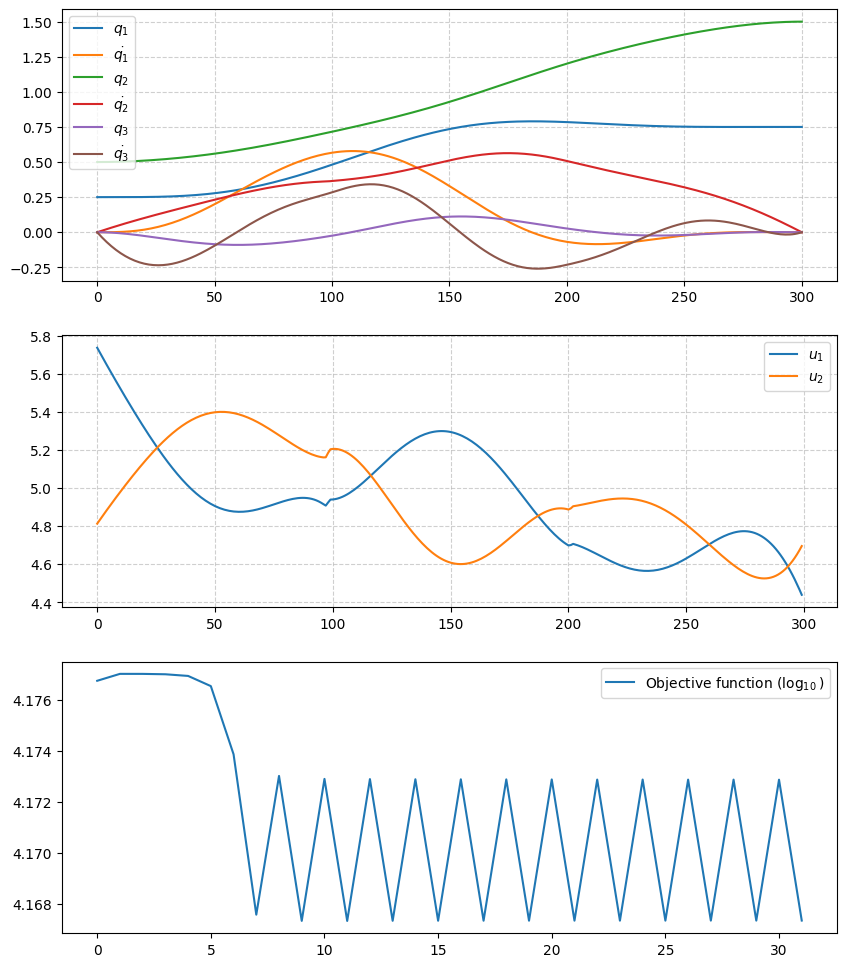

In [18]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(nrows=3, figsize=(10,12))

axes[0].grid(True, linestyle='--', alpha=0.6)

axes[0].plot(x_bar[0], label=r"$q_1$")
axes[0].plot(x_bar[1], label=r"$\dot{q_1}$")
axes[0].plot(x_bar[2], label=r"$q_2$")
axes[0].plot(x_bar[3], label=r"$\dot{q_2}$")
axes[0].plot(x_bar[4], label=r"$q_3$")
axes[0].plot(x_bar[5], label=r"$\dot{q_3}$")
axes[0].legend()

axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].plot(u1_bar, label=r"$u_1$")
axes[1].plot(u2_bar, label=r"$u_2$")
axes[1].legend()

axes[2].plot(np.log10(cost_list), label=r"Objective function ($\log_{10}$)")
axes[2].legend()

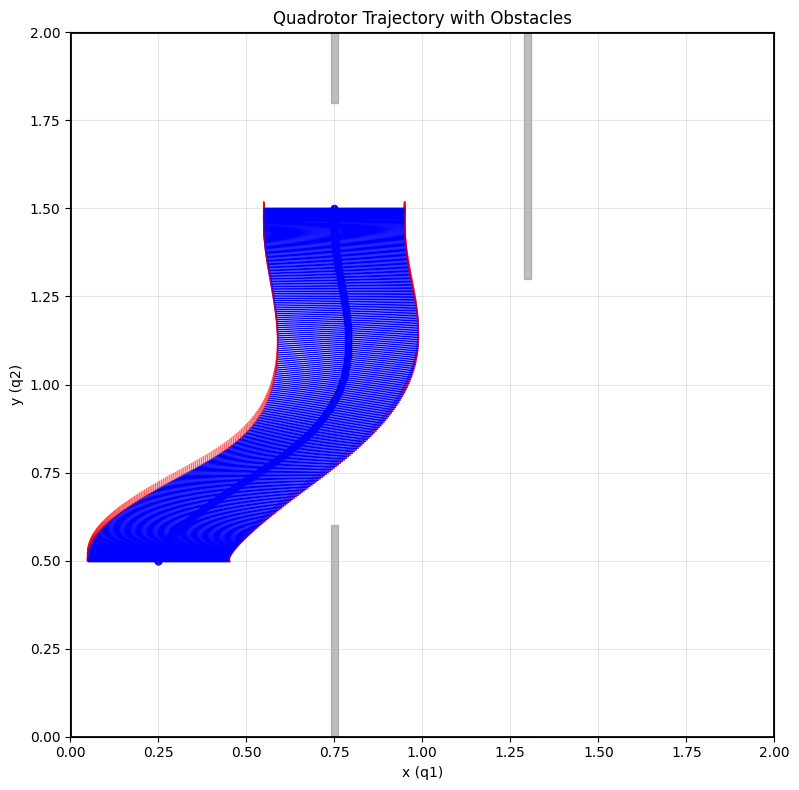

In [19]:
from plot_utils import *
import numpy as np

q_traj = np.array([x_bar[0, :], x_bar[2, :],x_bar[4, :]]).T
u_traj = np.array([u1_bar, u2_bar]).T
plot_trajectory(2, 2, {'r': .2}, 
    [{'x': .75, 'uh': .2, 'bh': .6}, 
    {'x': 1.3, 'uh': 0.7, 'bh': 0}], 
    q_traj, 
    u_traj)

## IPOPT

Use interior point optimization built in cvxpy to solve problem

In [1]:
!pip install git+https://github.com/cvxpy/cvxpy.git

  Cloning https://github.com/cvxpy/cvxpy.git to /tmp/pip-req-build-2y75692z
  Running command git clone --filter=blob:none --quiet https://github.com/cvxpy/cvxpy.git /tmp/pip-req-build-2y75692z
  Resolved https://github.com/cvxpy/cvxpy.git to commit 59cbc6c1b2d059f04ea06fe0063c23c825e8b57b
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [8]:
"""
Optimize a planar quadrotor trajectory using cvxpy with IPOPT (nonlinear solver).

This script follows the setup in optim_test.ipynb but uses the full nonlinear
discrete dynamics in quadrotor_dynamics.f_discrete and solves the resulting
nonconvex NLP with IPOPT via cvxpy: prob.solve(nlp=True, solver=cp.IPOPT).

Requirements:
- cvxpy built with IPOPT support (cyipopt installed and cvxpy from a recent
  branch that includes IPOPT interface). If IPOPT is not available, the script
  will raise an informative error.

Usage: run as a script. It will print solver status and final trajectory and
controls.
"""
import numpy as np
import cvxpy as cp
from quadrotor_dynamics import f_discrete, m, g, I, r


def solve_quadrotor(N=300, h=0.01, u_max=10.0):
    # State: x = [q1, v1, q2, v2, q3, w]
    x0 = np.array([0.25, 0.0, 0.5, 0.0, 0.0, 0.0])
    xT = np.array([0.75, 0.0, 1.5, 0.0, 0.0, 0.0])

    # Decision variables
    x = cp.Variable((6, N + 1))
    u1 = cp.Variable(N)
    u2 = cp.Variable(N)

    constraints = []
    constraints += [x[:, 0] == x0]
    constraints += [x[:, N] == xT]

    # Dynamics constraints using the nonlinear discrete dynamics
    for k in range(N):
        xk = x[:, k]
        uk = cp.hstack([u1[k], u2[k]])
        x_next = f_discrete(xk, uk, h)

        constraints += [x[:, k + 1] == x_next]

    # Control bounds
    constraints += [u1 >= 0, u1 <= u_max]
    constraints += [u2 >= 0, u2 <= u_max]

    # Objective: minimize control effort
    objective = cp.Minimize(cp.sum_squares(u1) + cp.sum_squares(u2))

    problem = cp.Problem(objective, constraints)

    print("Solving with IPOPT (nlp=True, solver=cp.IPOPT). This may take a while...")
    # Solve as a nonlinear program
    try:
        problem.solve(nlp=True, solver=cp.IPOPT, verbose=True)
    except Exception as e:
        raise RuntimeError(
            "IPOPT solve failed. Ensure cyipopt and a compatible cvxpy build are installed. "
            f"Original error: {e}"
        )

    print(f"Status: {problem.status}, Objective: {problem.value}")
    return x.value, u1.value, u2.value, problem


if __name__ == '__main__':
    x_traj, u1_traj, u2_traj, problem = solve_quadrotor(N=200, h=0.01, u_max=10.0)
    print("x shape:", x_traj.shape)
    print("u1 shape:", u1_traj.shape)
    print("u2 shape:", u2_traj.shape)


(CVXPY) May 14 09:51:43 PM: Your problem has 1606 variables, 2012 constraints, and 0 parameters.
(CVXPY) May 14 09:51:43 PM: It is compliant with the following grammars: 
(CVXPY) May 14 09:51:43 PM: DCP verification time: 0.0003 seconds.
(CVXPY) May 14 09:51:43 PM: Expression tree has 10 nodes.
(CVXPY) May 14 09:51:43 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) May 14 09:51:43 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) May 14 09:51:43 PM: Your problem is compiled with the CPP canonicalization backend.


Solving with IPOPT (nlp=True, solver=cp.IPOPT). This may take a while...
                                     CVXPY                                     
                            v1.9.0.dev0+256.9ff523c                            
This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.2.

Number of nonzeros in equality constraint Jacobian...:     7012
Number of nonzeros in inequality constraint Jacobian.:      800
Number of nonzeros in Lagrangian Hessian.............:     1200

Total number of variables............................:     2806
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:     2412
Total number of inequality constraints...............:      800
        inequality constraints with only lower bounds:      800
   inequality constraints with lower and upper bounds:

In [12]:
a=problem.value

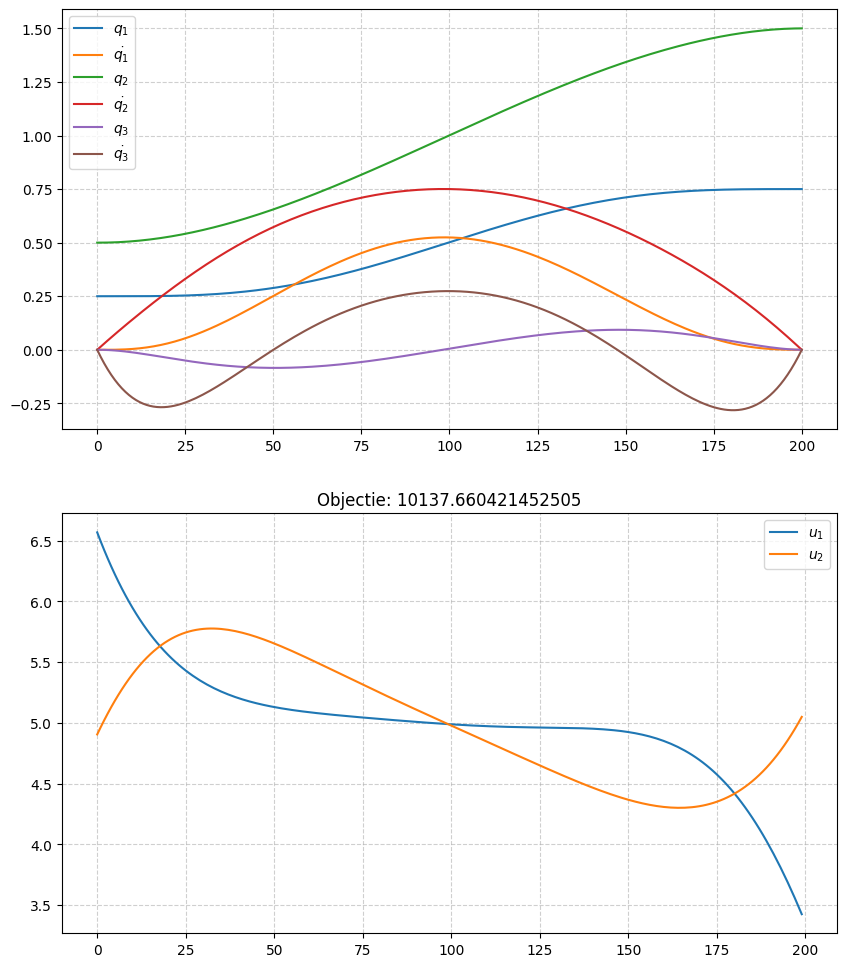

In [15]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(nrows=2, figsize=(10,12))

axes[0].grid(True, linestyle='--', alpha=0.6)

axes[0].plot(x_traj[0], label=r"$q_1$")
axes[0].plot(x_traj[1], label=r"$\dot{q_1}$")
axes[0].plot(x_traj[2], label=r"$q_2$")
axes[0].plot(x_traj[3], label=r"$\dot{q_2}$")
axes[0].plot(x_traj[4], label=r"$q_3$")
axes[0].plot(x_traj[5], label=r"$\dot{q_3}$")
axes[0].legend()

axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].plot(u1_traj, label=r"$u_1$")
axes[1].plot(u2_traj, label=r"$u_2$")
plt.title(f"Objectie: {problem.value}")
axes[1].legend()

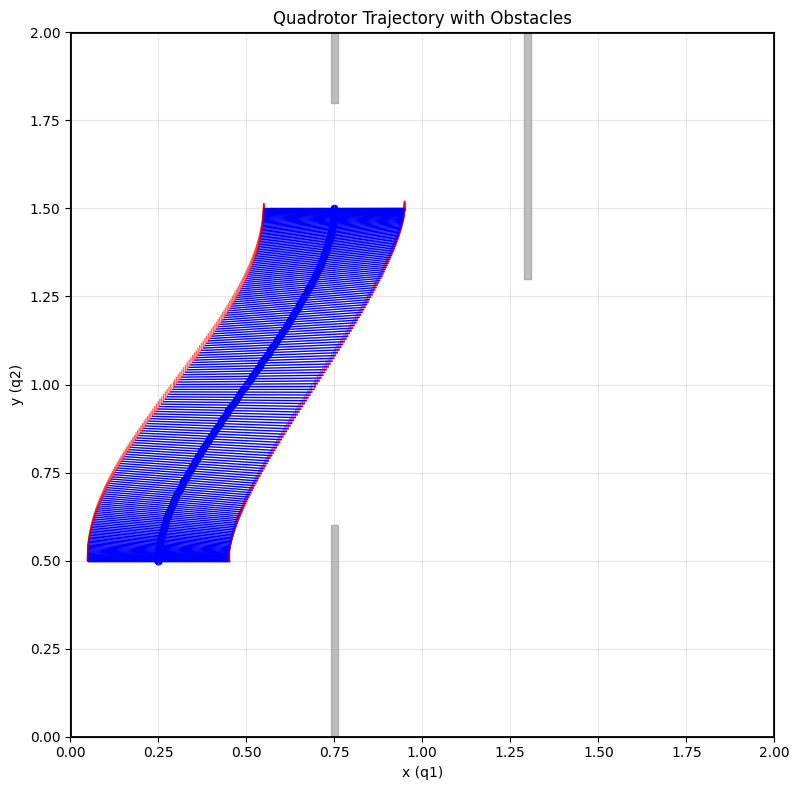

In [16]:
from plot_utils import *
import numpy as np

q_traj = np.array([x_traj[0, :], x_traj[2, :],x_traj[4, :]]).T
u_traj = np.array([u1_traj, u2_traj]).T
plot_trajectory(2, 2, {'r': .2}, 
    [{'x': .75, 'uh': .2, 'bh': .6}, 
    {'x': 1.3, 'uh': 0.7, 'bh': 0}], 
    q_traj, 
    u_traj)